In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Input, Multiply, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.layers.experimental.preprocessing import RandomRotation, RandomZoom, RandomTranslation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt


In [3]:
def crop_image_initial(image):
    print(image.shape)
    __, height, width, _ = image.shape
    cropped_image = tf.image.crop_to_bounding_box(image, 400, 400, height - 1000, width - 800)
    return cropped_image

In [4]:
def convert_to_grayscale(image):
    gray = tf.image.rgb_to_grayscale(image)
    return gray

In [5]:
def create_binary_mask(image, threshold = 0.95):
    binary_mask = tf.where(image > threshold, 1.0, 0.0)
    return binary_mask

In [6]:
def find_centre(mask):
    positions = tf.where(mask == 1.0)
    mean_position = tf.reduce_mean(tf.cast(positions, tf.float32), axis=0)
    center_y = tf.cast(mean_position[0], tf.int32)
    center_x = tf.cast(mean_position[1], tf.int32)
    return center_y, center_x

In [7]:
def crop_around_center(image, center_y, center_x, size=500):
    half_size = size // 2
    start_y = tf.maximum(center_y - half_size, 0)
    start_x = tf.maximum(center_x - half_size, 0)
    cropped_image = tf.image.crop_to_bounding_box(image, start_y, start_x, size, size)
    return cropped_image


In [8]:


def preprocess_image(image):
    cropped_image = crop_image_initial(image)
    # grayscale_img = convert_to_grayscale(cropped_image)
    # binary_mask = create_binary_mask(grayscale_img, 0.95)
    # center_y, center_x  = find_centre(binary_mask)
    # final_cropped_image = crop_around_center(cropped_image, center_y, center_x, 500)
    image = tf.image.resize(cropped_image, [224, 224])
    return image

def preprocess_image_map_fn(image, label):
    return preprocess_image(image), label


In [9]:
data_augmentation = tf.keras.Sequential([
    RandomRotation(0.2),  # Rotate the image by a factor of 20%
    RandomZoom(0.1),      # Zoom the image by a factor of 20%
    RandomTranslation(0.1, 0.1)  # Translate the image by a factor of 10%
])


In [10]:
def spatial_attention_module(input_feature):
    avg_pool = tf.reduce_mean(input_feature, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(input_feature, axis=-1, keepdims=True)
    concat = tf.concat([avg_pool, max_pool], axis=-1)
    attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    return Multiply()([input_feature, attention])


In [11]:
def build_resnet50_with_attention(input_shape):
    input_tensor = Input(shape=input_shape)
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=input_tensor)
    
    # Add attention module
    x = base_model.get_layer("conv4_block6_out").output
    x = spatial_attention_module(x)
    
    # rest of the ResNet50 layers
    x = base_model.get_layer("conv5_block1_out")(x)
    x = GlobalAveragePooling2D()(x)
    x = Flatten()(x)
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=input_tensor, outputs=output)
    return model

input_shape = (224, 224, 3)  
#model = build_resnet50_with_attention(input_shape)
model = tf.keras.models.load_model('90_resnet_attn.h5')
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 1e-3), loss='binary_crossentropy', metrics=['accuracy'])


In [12]:
def load_and_preprocess_data(data_dir, validation_split=0.30, batch_size=32):
    train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        validation_split=validation_split,
        subset='training',
        seed=123,
        image_size=(2048, 1536),
        batch_size=batch_size,
        label_mode='binary'
    ).map(lambda x, y: (data_augmentation(x, training=True), y)).map(preprocess_image_map_fn)

    validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        validation_split=validation_split,
        subset='validation',
        seed=123,
        image_size=(2048, 1536),
        batch_size=batch_size,
        label_mode='binary'
    )

    val_batches = len(validation_dataset)
    test_batches = val_batches // 2
    val_batches = val_batches = test_batches
    test_dataset = validation_dataset.take(test_batches)
    validation_dataset = validation_dataset.skip(test_batches)
    test_dataset = test_dataset.map(preprocess_image_map_fn)
    validation_dataset = validation_dataset.map(preprocess_image_map_fn)
    return train_dataset, validation_dataset, test_dataset

data_dir = "D:\dataset_SIDDHI"
train_dataset, validation_dataset, test_dataset = load_and_preprocess_data(data_dir)
print(f"{len(train_dataset)}, {len(validation_dataset)}, {len(test_dataset)}")
print(f"{len(train_dataset)} {len(validation_dataset)}")


Found 9000 files belonging to 2 classes.
Using 6300 files for training.
(None, 2048, 1536, 3)
Found 9000 files belonging to 2 classes.
Using 2700 files for validation.
(None, 2048, 1536, 3)
(None, 2048, 1536, 3)
197, 43, 42
197 43


In [14]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [15]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_resnet_attn.h5', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

In [ ]:
model.fit(train_dataset, validation_data=validation_dataset, epochs=60, batch_size=32, callbacks = [early_stopping, model_checkpoint, reduce_lr])


Epoch 1/60
197/197 [==============================] - 1159s 5s/step - loss: 0.6051 - accuracy: 0.7103 - val_loss: 0.7736 - val_accuracy: 0.7235 - lr: 0.0010
Epoch 2/60
197/197 [==============================] - 900s 5s/step - loss: 0.5490 - accuracy: 0.7329 - val_loss: 1.0165 - val_accuracy: 0.6556 - lr: 0.0010
Epoch 3/60
197/197 [==============================] - 893s 5s/step - loss: 0.5296 - accuracy: 0.7494 - val_loss: 0.6117 - val_accuracy: 0.7345 - lr: 0.0010
Epoch 4/60
197/197 [==============================] - 913s 5s/step - loss: 0.5264 - accuracy: 0.7521 - val_loss: 0.5625 - val_accuracy: 0.7500 - lr: 0.0010
Epoch 5/60
197/197 [==============================] - 908s 5s/step - loss: 0.5162 - accuracy: 0.7552 - val_loss: 0.5692 - val_accuracy: 0.7603 - lr: 0.0010
Epoch 6/60
197/197 [==============================] - 897s 5s/step - loss: 0.5083 - accuracy: 0.7606 - val_loss: 0.5272 - val_accuracy: 0.7611 - lr: 0.0010
Epoch 7/60
197/197 [==============================] - 897s 5s/s

In [16]:
new_model = tf.keras.models.load_model('cropped_resnet_1.h5')
test_results = {}
test_results['Model'] = new_model.evaluate(test_dataset)
print(f"test_accuracy: {test_results}")

42/42 [==============================] - 25s 285ms/step - loss: 0.4341 - accuracy: 0.8110
test_accuracy: {'Model': [0.4341195523738861, 0.8110119104385376]}


In [ ]:
def load_and_preprocess_image(image_path):
    # Load the image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)
    image = preprocess_image(image)
    # Add a batch dimension
    image = 
    return image

image_path = 'complete/normal/Normal10784.jpg'
image = load_and_preprocess_image(image_path)

# Make predictions
prediction = model.predict(image)
predicted_class = np.round(prediction).astype(int)

# Output the result
print(f'Predicted class: {predicted_class[0][0]}')


SyntaxError: invalid syntax (3464926922.py, line 7)

In [17]:
def extract_images_and_labels(dataset):
    images = []
    labels = []
    for image_batch, label_batch in dataset.take(len(dataset)):
        images.extend(image_batch.numpy())
        labels.extend(label_batch.numpy())
    return np.array(images), np.array(labels)

val_images, val_labels = extract_images_and_labels(test_dataset)

1/1 [==============================] - ETA: 0s

C:\Users\aruna\AppData\Local\Temp\ipykernel_176132\4265830126.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f'True: {int(true_label)}, Pred: {pred_label}')


1/1 [==============================] - 0s 12ms/step


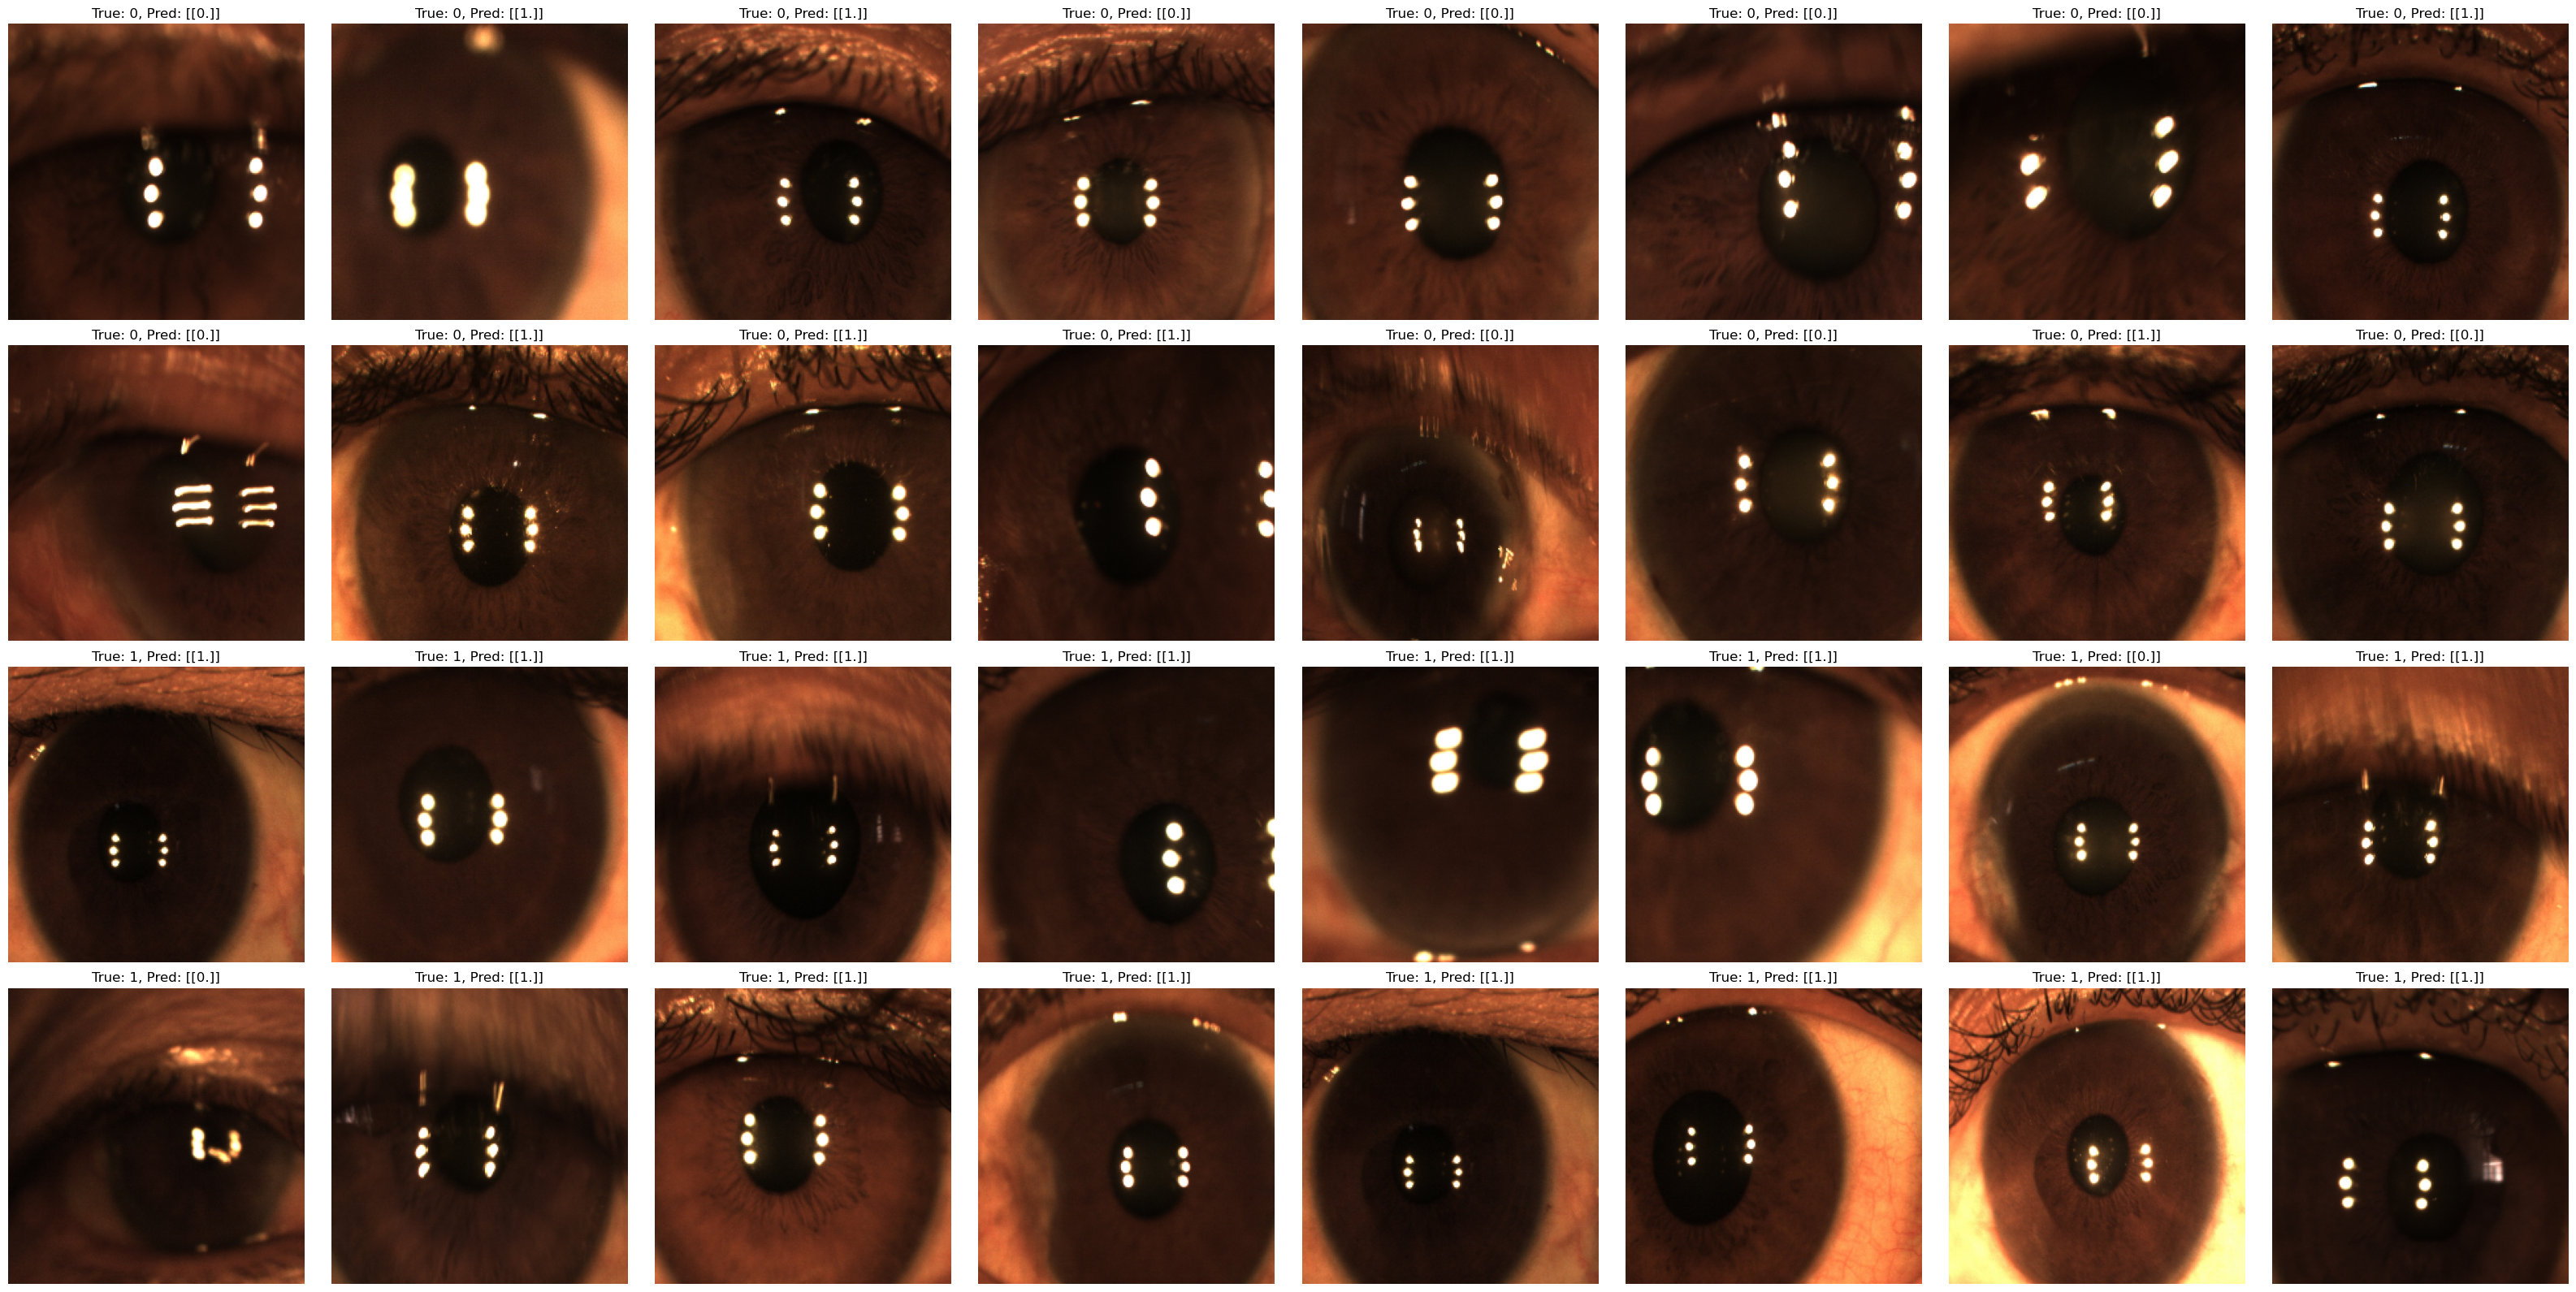

In [20]:
import matplotlib.pyplot as plt
import random


def display_predictions(model, val_images, val_labels):
    plt.figure(figsize=(32, 16))
    indices = []
    for label in [0, 1]:
        label_indices = np.where(val_labels == label)[0]
        indices.extend(random.sample(list(label_indices), 8))
        indices.extend(random.sample(list(label_indices), 8))
    
    for i, idx in enumerate(indices):
        img = val_images[idx]
        true_label = val_labels[idx]
        pred_label = ((model.predict(np.expand_dims(img, axis=0)))).round(0)

        plt.subplot(4, 8, i+1)
        plt.imshow(img.squeeze() / 255)
        plt.title(f'True: {int(true_label)}, Pred: {pred_label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display predictions
display_predictions(new_model, val_images, val_labels)
